# Phase 3

In [3]:
import argparse
import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, Gemma3ForCausalLM
from datasets import load_from_disk
from time import time

import threading
from torch.utils.tensorboard import SummaryWriter
from torch.cuda.amp import autocast, GradScaler

def check_for_nans(model, loss, experiment):
    # Check loss
    if torch.isnan(loss):
        print("❌ Loss is NaN!")
        print(experiment['experiment_name'])

    # Check each parameter
    for name, param in model.named_parameters():
        if torch.isnan(param).any():
            print(f"❌ NaNs found in parameter: {name}")
            print(experiment['experiment_name'])
        if param.grad is not None and torch.isnan(param.grad).any():
            print(f"❌ NaNs found in gradient of: {name}")
            print(experiment['experiment_name'])

def teacher_prep(model, input_ids_L, attention_mask_L, distributions):
    with torch.no_grad():
        input_ids_L[0], attention_mask_L[0] = input_ids_L[0].to(devices[1]), attention_mask_L[0].to(devices[1])
        out = model.forward(input_ids_L[0], attention_mask_L[0], return_dict=True, use_cache=False, output_hidden_states=False)
        # torch.cuda.synchronize()
        if torch.isnan(out['logits']).any(): 
            print(f"NaNs in raw logits teacher! {torch.isnan(out['logits']).nonzero()} {torch.isnan(out['logits']).nonzero().shape}")
            print(experimentjson['backward_steps'], input_ids_L[0])
        distributions.append(F.log_softmax(out['logits'] - out['logits'].max(dim=-1, keepdim=True).values, dim=-1).to(devices[0]))
        input_ids_L[0] = input_ids_L[0].to(devices[0])
        attention_mask_L[0] = attention_mask_L[0].to(devices[0])

def get_student_distribution(student_model,input_ids, attention_mask, last_teacher_distribution, hidden_states, vanilla_distributions, original_losses):
    with torch.no_grad():
        # backbone_out = student_model.model(input_ids.to(devices[1]), attention_mask.to(devices[1]), return_dict=True,use_cache=False)
        backbone_out = student_model.model(input_ids, attention_mask, return_dict=True,use_cache=False)
        logits = student_model.lm_head(backbone_out.last_hidden_state)
        if torch.isnan(logits).any(): 
            print(f"NaNs in raw logits student! {torch.isnan(logits).nonzero()} {torch.isnan(logits).nonzero().shape}")
        student_probs = F.log_softmax(logits - logits.max(dim=-1, keepdim=True).values, dim=-1)
        original_loss = loss_fn(student_probs, last_teacher_distribution[0])
    original_losses.append(original_loss.to(devices[2]))
    hidden_states.append(backbone_out.last_hidden_state.to(devices[2]))
    last_teacher_distribution[0] = last_teacher_distribution[0].to(devices[2])
    vanilla_distributions.append(student_probs.to(devices[2]))

def get_decoder_residuals_sparse(inflated_decoder, hidden_state, vanilla_distribution, experiment):
    if 'foward_inject' in experiment:
        return inflated_decoder.forward_inject(hidden_state, vanilla_distribution)
    residuals = inflated_decoder(hidden_state)
    if experiment['backward_steps'] % 500 == 0:
        experiment['writer'].add_histogram("Residuals", residuals.view(-1), experiment['backward_steps'])
    # print(residuals.shape)
    # experiment['writer'].add_image('heatmap/residuals', residuals.reshape(1, 4000, -1), experiment['backward_steps'])
    # print(residuals.shape)
    # print("Decoder sparse delta logits:", residuals.max().item(), residuals.min().item())
    return inflated_decoder.inject(residuals, vanilla_distribution)

def normalize(x): return x / x.sum(dim=-1, keepdim=True)

def loss_fn(input_dist, target_dist, experiment=None):
    input_dist, target_dist = input_dist.to(torch.float32)[...,:VOCABSIZE], target_dist.to(torch.float32)[...,:VOCABSIZE]
    if torch.isnan(input_dist).any(): print (f"{experiment} NaN in student dist!")
    if torch.isnan(target_dist).any(): print(f"{experiment} NaN in teacher dist!")
    # print(f"{experiment} input_dist.min:", input_dist.min().item())
    # print(f"{experiment} target_dist.min:", target_dist.min().item())

    out = torch.nn.functional.kl_div(input_dist.reshape(-1, VOCABSIZE), target_dist.reshape(-1, VOCABSIZE), log_target=True, reduction='batchmean')#.to(torch.bfloat16)
    if torch.isnan(out): print(f"{experiment} NaN in final KL loss!")

    # input_dist = torch.clamp(input_dist, min=1e-8)
    # target_dist = torch.clamp(target_dist, min=1e-8)

    # target_dist = target_dist.to(input_dist.device)
    # tempi, tempt = normalize(input_dist[...,:VOCABSIZE]), normalize(target_dist[...,:VOCABSIZE])
    # log_tempi = tempi.log().contiguous()
    # log_tempt = tempt.log().contiguous()
    # out = (tempt * (log_tempt - log_tempi)).sum() / tempi.size(0)
    
    # if experiment is not None and (e['backward_steps'] + 1) % e['accumulation_steps'] == 0:
    #     debug_loss = tempt * (log_tempt - log_tempi)
    #     # print('debug_loss shape', debug_loss.shape)
    #     e['debug_losses'] = e.get('debug_losses', []) + [debug_loss[-1:, ...].clone().cpu().detach()]
    #     e['debug_tempi']  = e.get('debug_tempi' , []) + [ log_tempi[-1:, ...].clone().cpu().detach()]
    #     e['debug_tempt']  = e.get('debug_tempt' , []) + [     tempt[-1:, ...].clone().cpu().detach()]
    #     e['debug_logtempt']  = e.get('debug_logtempt' , []) + [ log_tempt[-1:, ...].clone().cpu().detach()]
    #     e['debug_decoder'] = e.get('debug_decoder', []) + [d.proj.weight.clone().cpu().detach()]
    #     e['debug_hidden']  = e.get('debug_hidden', []) + [h.clone().cpu().detach()]

    return out

def learn_one_step_multi(optimizer, inflated_decoder, last_hidden_state, teacher_distribution, experiment):
    last_hidden_state = last_hidden_state.detach().clone().to(inflated_decoder.device, non_blocking=True)
    if isinstance(teacher_distribution, tuple):
        # teacher_distribution is a tuple of (vanilla_distribution, last_teacher_distribution)
        v_dist = teacher_distribution[0].detach().clone().to(inflated_decoder.device, non_blocking=True)
        t_dist = teacher_distribution[1].detach().clone().to(inflated_decoder.device, non_blocking=True)
        decoder_distribution = get_decoder_residuals_sparse(inflated_decoder, last_hidden_state, v_dist, experiment)
    else:
        t_dist = teacher_distribution.detach().clone().to(inflated_decoder.device, non_blocking=True)
        last_hidden_state, decoder_distribution = get_decoder_distribution(inflated_decoder, last_hidden_state)
    
    # [4, 1K, 200K]
    # loss = loss_fn(decoder_distribution, teacher_distribution, (experiment, inflated_decoder, last_hidden_state)) / experiment['accumulation_steps']
    # loss = loss_fn(decoder_distribution, t_dist, 'learn') / experiment['accumulation_steps']
    loss = loss_fn(decoder_distribution, t_dist, 'learn') / experiment['accumulation_steps']
    # scaler.scale(loss).backward()
    
    # check_for_nans(inflated_decoder, loss, experiment)

    loss.backward()
    experiment['backward_steps'] += 1

    if experiment['backward_steps'] % experiment['accumulation_steps'] == 0:
        # scaler.step(optimizer)
        # scaler.update()
        optimizer.step()
        optimizer.zero_grad()

    if (experiment['backward_steps']-1) % (experiment['accumulation_steps']*configuration['log_step']) == 0:
        experiment['writer'].add_scalar('original loss', experiment['original_loss'] / experiment['accumulation_steps'], (experiment['backward_steps']-1) * configuration['batch_size'])
        # experiment['writer'].add_scalar('improvement',  experiment['original_loss'] - loss.item() * experiment['accumulation_steps'], (experiment['backward_steps']-1) * configuration['batch_size'])
        experiment['writer'].add_scalar('improvement',  experiment['original_loss'] / experiment['accumulation_steps'] - loss.item(), (experiment['backward_steps']-1) * configuration['batch_size'])
        experiment['writer'].add_scalar('model loss',  loss.item(), (experiment['backward_steps']-1) * configuration['batch_size'])
class SparseResidualDecoder(torch.nn.Module):
    def __init__(self, student_model, counts, device, dtype, LN_FLAG, factor):
        torch.manual_seed(0)
        super().__init__()
        embedding_dim = student_model.lm_head.weight.shape[1]
        self.counts = counts.to(device)
        self.cummulative_neuron_counts = torch.nn.functional.pad(torch.cumsum(counts, dim=-1), (1,0), mode='constant', value=0)
        self.forward = self.forward_without_LN
        self.factor = factor
        if LN_FLAG:
            self.norm = torch.nn.LayerNorm(embedding_dim, device=device, dtype=dtype)
            self.forward = self.forward_with_LN
        self.proj = torch.nn.Linear(embedding_dim, counts.sum(), bias=False).to(device=device, dtype=dtype)
        torch.nn.init.xavier_uniform_(self.proj.weight)
        with torch.no_grad():
            self.proj.weight.data *= factor
            # if LN_FLAG:
            #     self.norm.weight.data *= factor
            #     self.norm.bias.data *= factor
        self.device = device
    def forward_without_LN(self, x):
        x = self.proj(x)
        with torch.no_grad():
            stabilizers = x.max(dim=-1, keepdims=True).values.detach()
        
        inflated_logits = x - stabilizers
        accummulated_logits = torch.exp(inflated_logits).cumsum(dim=-1)

        accummulated_logits = torch.nn.functional.pad(accummulated_logits, (1,0), mode='constant', value=0)

        residuals = accummulated_logits[..., self.cummulative_neuron_counts[1:]] - accummulated_logits[..., self.cummulative_neuron_counts[:-1]]
        del accummulated_logits, stabilizers
        return residuals
    
    def forward_with_LN(self, x):
        x = self.norm(x)
        x = self.proj(x)
        if torch.isnan(x).any(): 
            print(f"NaNs in raw logits, forward fn! {torch.isnan(x).nonzero()} {torch.isnan(x).nonzero().shape}")

        with torch.no_grad():
            stabilizers = x.max(dim=-1, keepdims=True).values.detach()
        
        inflated_logits = x - stabilizers
        accummulated_logits = torch.exp(inflated_logits.float()).cumsum(dim=-1)

        accummulated_logits = torch.nn.functional.pad(accummulated_logits, (1,0), mode='constant', value=0)

        residuals = accummulated_logits[..., self.cummulative_neuron_counts[1:]] - accummulated_logits[..., self.cummulative_neuron_counts[:-1]]
        del accummulated_logits, stabilizers
        return residuals
    
    def inject(self, residuals, vanilla_distribution):
        # t = vanilla_distribution.exp()
        # t[..., TOKENS_OF_INTEREST[:residuals.shape[-1]]] += residuals * 0
        # t = torch.clamp(t, min=1e-6)
        # logt = torch.log(t) - torch.log(t.sum(dim=-1, keepdim=True))
        # return logt

        # print("vdist sums", vanilla_distribution.sum(dim=-1)[...,:5])
        t = vanilla_distribution.float().exp()
        # print("t1 sums", t.sum(dim=-1)[...,:5])
        t[..., TOKENS_OF_INTEREST[:residuals.shape[-1]]] *= residuals / self.counts #* self.factor
        t = normalize(torch.clamp(t, min=1e-10))
        # print("t2 sums", t.sum(dim=-1)[...,:5])
        t = t.log()
        # print("injected sums", t.sum(dim=-1)[...,:5])

        return t
    def forward_inject(self, x, v_dist):
        x = self.norm(x)
        x = self.proj(x)
        if torch.isnan(x).any():
            print(f"NaNs in raw logits, forward fn! {torch.isnan(x).nonzero()} {torch.isnan(x).nonzero().shape}")
        with torch.no_grad():
            stabilizers = x.max(dim=-1, keepdims=True).values.detach()
        
        inflated_logits = x - stabilizers
        del stabilizers
        
        t = v_dist.float().exp()        
        
        mapped = torch.repeat_interleave(v_dist[..., :TOKENS_OF_INTEREST[self.counts.size(-1)]].float(), self.counts, dim=-1)
        mapped += inflated_logits
        # mapped -= self.counts.log() # Either this or divide by counts after accummulation 
        
        ''' Do we need this part again?
        stabilizers = mapped.max(dim=-1, keepdims=True).values.detach()
        mapped -= stabilizers
        '''
        mapped = mapped.exp().cumsum(dim=-1)
        t[..., :TOKENS_OF_INTEREST[self.counts.size(-1)]] = (mapped[..., self.cummulative_neuron_counts[1:]] - mapped[...]) / self.counts
        del mapped 
        t = normalize(torch.clamp(t, min=1e-10))
        return t.log()
def train_loop(configuration):
    ## SETUP
    student_model = configuration['student_model']
    teacher_model = configuration['teacher_model']
    dataloader = configuration['loader']
    for i, experiment in enumerate(configuration['experiments']):
        experiment['writer'] = SummaryWriter(f"{configuration['log_path']}/{experiment['experiment_name']}")
        decoder_device = devices[i+2]
        counts = experiment['neuron_counts']
        experiment['inflated_decoder'] = SparseResidualDecoder(student_model, counts, decoder_device, configuration['type'], configuration['ln']=="1", experiment['init_factor'])
        experiment['optimizer'] = experiment['optimizer'](experiment['inflated_decoder'].parameters())
        experiment['optimizer'].zero_grad()
        experiment['backward_steps'] = 0

    hidden_states   = []
    teacher_distributions   = []
    vanilla_distributions = []
    decoder_results = []
    original_losses = []
    ## INITIAL VALUES
    for i, batch in enumerate(dataloader):
        lines = batch['text']
        batch = tokenizer(lines, max_length=configuration['line_length'], padding=True, truncation=True, return_tensors="pt")
        input_ids_L = [batch['input_ids']]
        attention_mask_L = [batch['attention_mask']]
        if (batch['input_ids'][:, 0] == 0).any():
            continue
        if i == 0:
            t1 = threading.Thread(target=teacher_prep, args=(teacher_model, input_ids_L, attention_mask_L, teacher_distributions))
            t1.start()
            t1.join()
            past_input_ids = input_ids_L[0]
            past_attention_masks = attention_mask_L[0]
            last_teacher_distribution_L = [teacher_distributions.pop(0)]            
            continue
        if i == 1:
            t1 = threading.Thread(target=teacher_prep, args=(teacher_model, input_ids_L, attention_mask_L, teacher_distributions))
            t2 = threading.Thread(target=get_student_distribution, args=(student_model, past_input_ids, past_attention_masks, last_teacher_distribution_L, hidden_states, vanilla_distributions, original_losses))
            t1.start()
            t2.start()
            t1.join()
            t2.join()
            past_input_ids = input_ids_L[0]
            past_attention_masks = attention_mask_L[0]
            last_hidden_state = hidden_states.pop(0)
            last_last_teacher_dist = last_teacher_distribution_L[0]
            
            last_teacher_distribution_L = [teacher_distributions.pop(0)]
            last_vanilla_dist = vanilla_distributions.pop(0)
            old_original_loss = original_losses.pop(0)
            continue
        t1 = threading.Thread(target=teacher_prep, args=(teacher_model, input_ids_L, attention_mask_L, teacher_distributions))
        t2 = threading.Thread(target=get_student_distribution, args=(student_model, past_input_ids, past_attention_masks, last_teacher_distribution_L, hidden_states, vanilla_distributions, original_losses))
        t1.start()
        t2.start()
        
        # if configuration['target'] == 'residual':
        #     t3 = threading.Thread(target=learn_one_step_multi, args=(configuration['optimizer'], configuration['inflated_decoder'], cum_neurons, last_hidden_state, (last_vanilla_dist, last_last_teacher_dist), {'writer':configuration['writer'], 'steps':i}))
        # else:
        #     t3 = threading.Thread(target=learn_one_step_multi, args=(configuration['optimizer'], configuration['inflated_decoder'], cum_neurons, last_hidden_state, last_last_teacher_dist, {'writer':configuration['writer'], 'steps':i}))
        # t3.start()
        
        consumer_threads = []
        for experiment in configuration['experiments']:
            experiment['original_loss'] = old_original_loss
            if configuration['target'] == 'residual':
                t3 = threading.Thread(target=learn_one_step_multi, args=(experiment['optimizer'], experiment['inflated_decoder'], last_hidden_state, (last_vanilla_dist, last_last_teacher_dist), experiment))
            else:
                t3 = threading.Thread(target=learn_one_step_multi, args=(experiment['optimizer'], experiment['inflated_decoder'], last_hidden_state, last_last_teacher_dist, experiment))
            t3.start()
            consumer_threads.append(t3)
            
        
        t1.join()
        t2.join()
        for t3 in consumer_threads:
            t3.join()

        # decoder_loss = decoder_results.pop(0)

        # if (configuration['backward_steps']-1) % (configuration['accumulation_steps']*configuration['log_step']) == 0:
        #     writer.add_scalar('original loss', old_original_loss, configuration['backward_steps']-1)
        #     writer.add_scalar('improvement', decoder_loss-old_original_loss, configuration['backward_steps']-1)

        past_input_ids = input_ids_L[0]
        past_attention_masks = attention_mask_L[0]
        last_hidden_state = hidden_states.pop(0)
        last_last_teacher_dist = last_teacher_distribution_L[0]
        last_teacher_distribution_L = [teacher_distributions.pop(0)]
        last_vanilla_dist = vanilla_distributions.pop(0)
        old_original_loss = original_losses.pop(0)           

def collect_data_10M(configuration):
    def teacher_collect_fn(model, input_ids_L,attention_mask_L):
        with torch.no_grad():
            input_ids_L[0], attention_mask_L[0] = input_ids_L[0].to(devices[1]), attention_mask_L[0].to(devices[1])
            out = model.forward(input_ids_L[0], attention_mask_L[0], return_dict=True, use_cache=False, output_hidden_states=False)
            # torch.cuda.synchronize()
            teacher_probs = F.softmax(out['logits'], dim=-1)[..., TOKENS_OF_INTEREST]
            teacher_matrix.append(teacher_probs.cpu().detach().reshape(-1, 10_000).numpy())

    def student_collect_fn(student_model, input_ids, attention_mask):
        with torch.no_grad():
            # backbone_out = student_model.model(input_ids.to(devices[1]), attention_mask.to(devices[1]), return_dict=True,use_cache=False)
            out = student_model.forward(input_ids.to(devices[0]), attention_mask.to(devices[0]), return_dict=True,use_cache=False)
            logits = out['logits']
            student_probs = F.softmax(logits, dim=-1)[..., TOKENS_OF_INTEREST]
            student_matrix.append(student_probs.cpu().detach().reshape(-1, 10_000).numpy())
    ## SETUP
    student_model = configuration['student_model']
    teacher_model = configuration['teacher_model']
    dataloader = configuration['loader']
    
    teacher_matrix, student_matrix = [], []
    
    ## INITIAL VALUES
    for i, batch in enumerate(dataloader):
        lines = batch['text']
        batch = tokenizer(lines, max_length=configuration['line_length'], padding=True, truncation=True, return_tensors="pt")
        input_ids_L = [batch['input_ids']]
        attention_mask_L = [batch['attention_mask']]
        if (batch['input_ids'][:, 0] == 0).any():
            continue
        if i == 0:
            t1 = threading.Thread(target=teacher_collect_fn, args=(teacher_model, input_ids_L, attention_mask_L))
            t1.start()
            t1.join()
            past_input_ids = input_ids_L[0]
            past_attention_masks = attention_mask_L[0]
            continue
        t1 = threading.Thread(target=teacher_collect_fn, args=(teacher_model, input_ids_L, attention_mask_L))
        t2 = threading.Thread(target=student_collect_fn, args=(student_model, past_input_ids, past_attention_masks))
        t1.start()
        t2.start()            
        t1.join()
        t2.join()
        
        past_input_ids = input_ids_L[0]
        past_attention_masks = attention_mask_L[0]
        if i == 2500:
            break
    return teacher_matrix, student_matrix

def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument('--experiment_name', type=str, default='')
    parser.add_argument('--log_path', type=str, default='experiments')
    parser.add_argument('--log_step', type=int, default=10)
    parser.add_argument('--batch_size', type=int, default=4)
    parser.add_argument('--line_length', type=int, default=1000)
    parser.add_argument('--accumulation_steps', type=int, default=1)
    parser.add_argument('--target', type=str, choices=['prob', 'residual'], default='residual')
    parser.add_argument('--weight_type', type=str, choices=['fp32', 'bf16'], default='bf16')
    parser.add_argument('--devices', type=int, default=3, help='Number of devices to run the code on')
    parser.add_argument('--cutoffs', type=int, nargs='+', default=[1], help='Space-separated list of cutoff indices')
    parser.add_argument('--counts', type=int, nargs='+', default=[1], help='Space-separated list of neuron counts per cutoff segment')
    parser.add_argument('--layernorm', type=str, default='1', help='Determine whether to use layernorm or not in the inflated decoder')
    return parser.parse_args()

if  False and __name__ == "__main__":
    args = parse_args()
    TOKENS_OF_INTEREST = torch.tensor(np.fromfile("gemma3_TOI", dtype=np.int32))
    devices = [f'cuda:{i}' for i in range(args.devices)]
    
    weight_type = (torch.bfloat16 if args.weight_type == "bf16" else torch.float32)

    model   = Gemma3ForCausalLM.from_pretrained("google/gemma-3-1b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja", torch_dtype=weight_type, device_map = devices[0])  
    teacher = Gemma3ForCausalLM.from_pretrained("google/gemma-3-4b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja", torch_dtype=weight_type, device_map = devices[1])  
    tokenizer   = AutoTokenizer.from_pretrained("google/gemma-3-1b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja")
    ds = load_from_disk("/image-generation/imlloja/filtered-math")
    # ds = torch.utils.data.Subset(ds, range(10000, len(ds)))
    scaler = GradScaler()

    lr = 0.005
    neuron_counts = torch.ones(model.lm_head.weight.shape[0], dtype=torch.int32)
    print("Running experiment", args.experiment_name)
    configuration = {
        'log_path' : "debugging/new_inject/starting_point",
        'teacher_model' : teacher,
        'student_model' : model,
        'optimizer' : lambda y : lambda x : torch.optim.Adam(x, lr=y, eps=1e-6),
        'log_step' : 1,
        # 'accumulation_steps' : args.accumulation_steps,
        'target' : "residual",
        'type' : weight_type,
        'ln' : "1",
        'noise_init_fn' : lambda x : torch.nn.init.normal_(x, mean=0, std=0.03),
        'line_length' : 1000,
        'batch_size' : 4,
        'experiments' : [
            # {
            #     'cutoffs' : [0, 1],
            #     'counts'  : [0],
            #     'accumulation_steps' : 1,
            #     'init_factor' : 0,
            #     'lr' : 0.005
            # },
            # {
            #     'cutoffs' : [0, 1],
            #     'counts'  : [0],
            #     'accumulation_steps' : 10,
            #     'init_factor' : 0,
            #     'lr' : 0
            # },
            {
                'cutoffs' : [0, 1],
                'counts'  : [1],
                'accumulation_steps' : 1,
                'init_factor' : 0,
                'lr' : 0.005
            },
            {
                'cutoffs' : [0, 10000],
                'counts'  : [1],
                'accumulation_steps' : 1,
                'init_factor' : 0,
                'lr' : 0.005
            },
            {
                'cutoffs' : [0, 1],
                'counts'  : [1],
                'accumulation_steps' : 10,
                'init_factor' : 0,
                'lr' : 0
            },
            {
                'cutoffs' : [0, 10000],
                'counts'  : [1],
                'accumulation_steps' : 10,
                'init_factor' : 0,
                'lr' : 0
            },
            # {
            #     'cutoffs' : [0, 1000, 2000, 10000],
            #     'counts'  : [128, 64, 8],
            #     'accumulation_steps' : 1000,
            #     'init_factor' : 0
            # },
            # {
            #     'cutoffs' : [0, 400, 2000, 5000, 8000],
            #     'counts'  : [256, 64, 16, 2],
            #     'accumulation_steps' : 1000,
            #     'init_factor' : 0
            # },
            # {
            #     'cutoffs' : [0, 400, 5000, 8000],
            #     'counts'  : [256, 32, 2],
            #     'accumulation_steps' : 1000,
            #     'init_factor' : 0
            # },
            # {
            #     'cutoffs' : [0, 400, 2000, 5000, 8000],
            #     'counts'  : [256, 64, 16, 2],
            #     'accumulation_steps' : 500,
            #     'init_factor' : 0
            # },
            # {
            #     'cutoffs' : [0, 400, 5000, 8000],
            #     'counts'  : [256, 32, 2],
            #     'accumulation_steps' : 500,
            #     'init_factor' : 0
            # },
            # {
            #     'cutoffs' : [0, 400, 5000, 8000],
            #     'counts'  : [256, 32, 2],
            #     'accumulation_steps' : 1500,
            #     'init_factor' : 0
            # },
        ],
    }
    VOCABSIZE = tokenizer.vocab_size
        
    for experimentjson in configuration['experiments']:
        lr = experimentjson['lr']
        factor = experimentjson['init_factor']
        experimentjson['optimizer'] = configuration['optimizer'](lr)
        experimentjson['experiment_name'] = f"gemma1_gemma4_lr_{lr}_{weight_type}_batchsize_{configuration['batch_size']}_{configuration['target']}_accSteps={experimentjson['accumulation_steps']}_cutoffs _{experimentjson['cutoffs']}_counts _{experimentjson['counts']}_factor_{factor}{'_LN'if configuration['ln']=='1' else '_noLN'}"
        experimentjson['counts'] = torch.tensor(experimentjson['counts'])
        experimentjson['cutoffs'] = torch.tensor(experimentjson['cutoffs'])
        experimentjson['backward_steps'] = 0
        forward_diff = experimentjson['cutoffs'][1:] - experimentjson['cutoffs'][:-1]
        experimentjson['neuron_counts'] = torch.repeat_interleave(experimentjson['counts'], forward_diff)
        # for i in range(len(experimentjson['inflated_decoder_sizes']['cutoffs'])-1):
        #     counts, cutoffs = experimentjson['inflated_decoder_sizes']['counts'], experimentjson['inflated_decoder_sizes']['cutoffs']
        #     experimentjson['neuron_counts'][cutoffs[i] : cutoffs[i+1]] = counts[i]

    loader = torch.utils.data.DataLoader(ds, batch_size=configuration['batch_size'], shuffle=False)
    configuration['loader'] = loader
    
    train_loop(configuration)
    # main(configuration)
    # queues_loop(configuration)
    # naive(configuration)



In [ ]:
TOKENS_OF_INTEREST = torch.tensor(np.fromfile("gemma3_TOI", dtype=np.int32))
devices = [f'cuda:{i}' for i in [0,1,4,5,6,7]]

weight_type = (torch.bfloat16 if True or args.weight_type == "bf16" else torch.float32)

model   = Gemma3ForCausalLM.from_pretrained("google/gemma-3-1b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja", torch_dtype=weight_type, device_map = devices[0])  
teacher = Gemma3ForCausalLM.from_pretrained("google/gemma-3-4b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja", torch_dtype=weight_type, device_map = devices[1])  
tokenizer   = AutoTokenizer.from_pretrained("google/gemma-3-1b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja")
ds = load_from_disk("/image-generation/imlloja/filtered-math")
# ds = torch.utils.data.Subset(ds, range(10000, len(ds)))
scaler = GradScaler()

lr = 0.005
neuron_counts = torch.ones(model.lm_head.weight.shape[0], dtype=torch.int32)
print("Running experiment")
configuration = {
    'log_path' : "debugging/forward_inject/withdiv",
    'teacher_model' : teacher,
    'student_model' : model,
    'optimizer' : lambda y : lambda x : torch.optim.Adam(x, lr=y, eps=1e-6),
    'log_step' : 1,
    # 'accumulation_steps' : args.accumulation_steps,
    'target' : "residual",
    'type' : weight_type,
    'ln' : "1",
    'noise_init_fn' : lambda x : torch.nn.init.normal_(x, mean=0, std=0.03),
    'line_length' : 1000,
    'batch_size' : 4,
    'experiments' : [
        # {
        #     'cutoffs' : [0, 1],
        #     'counts'  : [0],
        #     'accumulation_steps' : 1,
        #     'init_factor' : 0,
        #     'lr' : 0.005
        # },
        # {
        #     'cutoffs' : [0, 1],
        #     'counts'  : [0],
        #     'accumulation_steps' : 10,
        #     'init_factor' : 0,
        #     'lr' : 0
        # },
        {
            'cutoffs' : [0, 1],
            'counts'  : [1],
            'accumulation_steps' : 1000,
            'init_factor' : 0,
            'lr' : 0.1
        },
        {
            'cutoffs' : [0, 10000],
            'counts'  : [1],
            'accumulation_steps' : 1000,
            'init_factor' : 0,
            'lr' : 0.1
        },
        {
            'cutoffs' : [0, 1],
            'counts'  : [1],
            'accumulation_steps' : 1000,
            'init_factor' : 0,
            'lr' : 0.1,
            'forward_inject' : True
        },
        {
            'cutoffs' : [0, 10000],
            'counts'  : [1],
            'accumulation_steps' : 1000,
            'init_factor' : 0,
            'lr' : 0.1,
            'forward_inject' : True
        },
        # {
        #     'cutoffs' : [0, 1000, 2000, 10000],
        #     'counts'  : [128, 64, 8],
        #     'accumulation_steps' : 1000,
        #     'init_factor' : 0
        # },
        # {
        #     'cutoffs' : [0, 400, 2000, 5000, 8000],
        #     'counts'  : [256, 64, 16, 2],
        #     'accumulation_steps' : 1000,
        #     'init_factor' : 0
        # },
        # {
        #     'cutoffs' : [0, 400, 5000, 8000],
        #     'counts'  : [256, 32, 2],
        #     'accumulation_steps' : 1000,
        #     'init_factor' : 0
        # },
        # {
        #     'cutoffs' : [0, 400, 2000, 5000, 8000],
        #     'counts'  : [256, 64, 16, 2],
        #     'accumulation_steps' : 500,
        #     'init_factor' : 0
        # },
        # {
        #     'cutoffs' : [0, 400, 5000, 8000],
        #     'counts'  : [256, 32, 2],
        #     'accumulation_steps' : 500,
        #     'init_factor' : 0
        # },
        # {
        #     'cutoffs' : [0, 400, 5000, 8000],
        #     'counts'  : [256, 32, 2],
        #     'accumulation_steps' : 1500,
        #     'init_factor' : 0
        # },
    ],
}
VOCABSIZE = tokenizer.vocab_size
    
for experimentjson in configuration['experiments']:
    lr = experimentjson['lr']
    factor = experimentjson['init_factor']
    experimentjson['optimizer'] = configuration['optimizer'](lr)
    experimentjson['experiment_name'] = f"{'one_step' if 'forward_inject' in experimentjson else 'two_steps'}_gemma1_gemma4_lr_{lr}_{weight_type}_batchsize_{configuration['batch_size']}_{configuration['target']}_accSteps={experimentjson['accumulation_steps']}_cutoffs _{experimentjson['cutoffs']}_counts _{experimentjson['counts']}_factor_{factor}{'_LN'if configuration['ln']=='1' else '_noLN'}"
    experimentjson['counts'] = torch.tensor(experimentjson['counts'])
    experimentjson['cutoffs'] = torch.tensor(experimentjson['cutoffs'])
    experimentjson['backward_steps'] = 0
    forward_diff = experimentjson['cutoffs'][1:] - experimentjson['cutoffs'][:-1]
    experimentjson['neuron_counts'] = torch.repeat_interleave(experimentjson['counts'], forward_diff)
    # for i in range(len(experimentjson['inflated_decoder_sizes']['cutoffs'])-1):
    #     counts, cutoffs = experimentjson['inflated_decoder_sizes']['counts'], experimentjson['inflated_decoder_sizes']['cutoffs']
    #     experimentjson['neuron_counts'][cutoffs[i] : cutoffs[i+1]] = counts[i]

loader = torch.utils.data.DataLoader(ds, batch_size=configuration['batch_size'], shuffle=False)
configuration['loader'] = loader

# train_loop(configuration)
# main(configuration)
# queues_loop(configuration)
# naive(configuration)



In [ ]:
import os
model_dir = '/image-generation/imlloja/distillation/models/forced_increments/adamw/fixed_alpha=1e-3/mean_normed_grads/BASELINE/weight_decay_100_gemma1_gemma4_lr_0.0001_torch.bfloat16_batchsize_4_residual_accSteps=10_cutoffs _[0, 1000]_counts _[10]_factor_0.001_LN'
files = sorted(os.listdir(model_dir), key=lambda x : int(x[:-4]))

In [2]:
modelpath10 = '/image-generation/imlloja/distillation/models/forced_increments/adamw/alpha0.1/weight_decay_0.1_gemma1_gemma4_lr_1e-05_torch.bfloat16_batchsize_4_residual_accSteps=2000_cutoffs _[0, 10000]_counts _[1]_factor_1_LN/10.pth'

modelpath330 = '/image-generation/imlloja/distillation/models/forced_increments/adamw/alpha0.1/weight_decay_0.1_gemma1_gemma4_lr_1e-05_torch.bfloat16_batchsize_4_residual_accSteps=2000_cutoffs _[0, 10000]_counts _[1]_factor_1_LN/330.pth'

cpt10 = torch.load(modelpath10)
cpt330 = torch.load(modelpath330)


In [3]:
m10=cpt10['proj.weight'].float()
m330=cpt330['proj.weight'].float()
print(m10.norm())
print(m330.norm())
print( (m10-m330).norm())

#.cpu().detach().numpy()

tensor(45.4458, device='cuda:3')
tensor(45.5725, device='cuda:3')
tensor(4.3406, device='cuda:3')


In [7]:
m10.shape

torch.Size([10000, 1152])

In [ ]:
cpt['proj.weight'].float().norm()#.cpu().detach().numpy()

In [48]:
cpt['proj.weight'].norm(dim=1).float().cpu().detach().numpy().max()

0.48046875

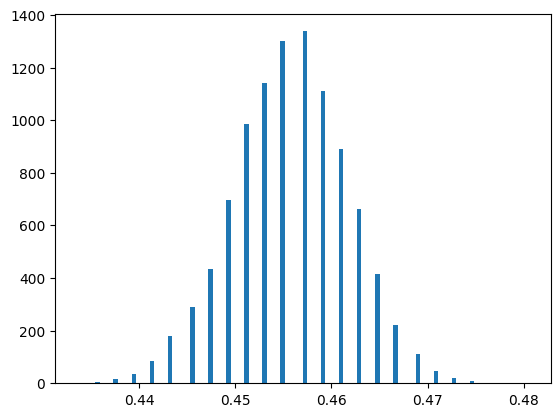

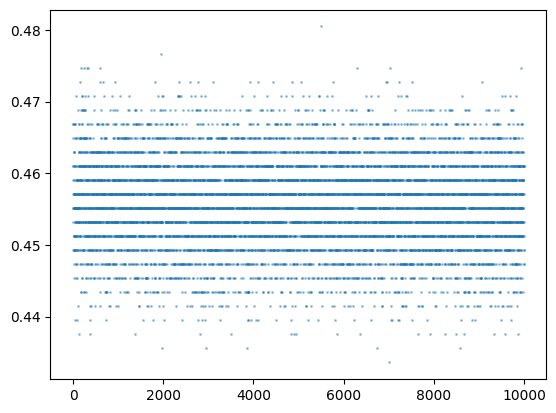

In [52]:
import matplotlib.pyplot as plt

plt.hist(cpt['proj.weight'].norm(dim=1).float().cpu().detach().numpy(), bins=100);
plt.show()
plt.scatter(np.arange(10000), cpt['proj.weight'].norm(dim=1).float().cpu().detach().numpy(), s=1, alpha=0.4)
# plt.ylim(0.4, 0.5)

In [2]:
TOKENS_OF_INTEREST = torch.tensor(np.fromfile("gemma3_TOI", dtype=np.int32))
devices = [f'cuda:{i}' for i in [0,1,4,5,6,7]]

weight_type = (torch.bfloat16 if True or args.weight_type == "bf16" else torch.float32)

model   = Gemma3ForCausalLM.from_pretrained("google/gemma-3-1b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja", torch_dtype=weight_type, device_map = devices[0])  
teacher = Gemma3ForCausalLM.from_pretrained("google/gemma-3-4b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja", torch_dtype=weight_type, device_map = devices[1])  
tokenizer   = AutoTokenizer.from_pretrained("google/gemma-3-1b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja")
ds = load_from_disk("/image-generation/imlloja/filtered-math")
# ds = torch.utils.data.Subset(ds, range(10000, len(ds)))
scaler = GradScaler()

lr = 0.005
neuron_counts = torch.ones(model.lm_head.weight.shape[0], dtype=torch.int32)
print("Running experiment")
configuration = {
    'log_path' : "debugging/forward_inject/withdiv",
    'teacher_model' : teacher,
    'student_model' : model,
    'optimizer' : lambda y : lambda x : torch.optim.Adam(x, lr=y, eps=1e-6),
    'log_step' : 1,
    # 'accumulation_steps' : args.accumulation_steps,
    'target' : "residual",
    'type' : weight_type,
    'ln' : "1",
    'noise_init_fn' : lambda x : torch.nn.init.normal_(x, mean=0, std=0.03),
    'line_length' : 1000,
    'batch_size' : 4,
    'experiments' : [
        # {
        #     'cutoffs' : [0, 1],
        #     'counts'  : [0],
        #     'accumulation_steps' : 1,
        #     'init_factor' : 0,
        #     'lr' : 0.005
        # },
        # {
        #     'cutoffs' : [0, 1],
        #     'counts'  : [0],
        #     'accumulation_steps' : 10,
        #     'init_factor' : 0,
        #     'lr' : 0
        # },
        {
            'cutoffs' : [0, 1],
            'counts'  : [1],
            'accumulation_steps' : 1000,
            'init_factor' : 0,
            'lr' : 0.1
        },
        {
            'cutoffs' : [0, 10000],
            'counts'  : [1],
            'accumulation_steps' : 1000,
            'init_factor' : 0,
            'lr' : 0.1
        },
        {
            'cutoffs' : [0, 1],
            'counts'  : [1],
            'accumulation_steps' : 1000,
            'init_factor' : 0,
            'lr' : 0.1,
            'forward_inject' : True
        },
        {
            'cutoffs' : [0, 10000],
            'counts'  : [1],
            'accumulation_steps' : 1000,
            'init_factor' : 0,
            'lr' : 0.1,
            'forward_inject' : True
        },
        # {
        #     'cutoffs' : [0, 1000, 2000, 10000],
        #     'counts'  : [128, 64, 8],
        #     'accumulation_steps' : 1000,
        #     'init_factor' : 0
        # },
        # {
        #     'cutoffs' : [0, 400, 2000, 5000, 8000],
        #     'counts'  : [256, 64, 16, 2],
        #     'accumulation_steps' : 1000,
        #     'init_factor' : 0
        # },
        # {
        #     'cutoffs' : [0, 400, 5000, 8000],
        #     'counts'  : [256, 32, 2],
        #     'accumulation_steps' : 1000,
        #     'init_factor' : 0
        # },
        # {
        #     'cutoffs' : [0, 400, 2000, 5000, 8000],
        #     'counts'  : [256, 64, 16, 2],
        #     'accumulation_steps' : 500,
        #     'init_factor' : 0
        # },
        # {
        #     'cutoffs' : [0, 400, 5000, 8000],
        #     'counts'  : [256, 32, 2],
        #     'accumulation_steps' : 500,
        #     'init_factor' : 0
        # },
        # {
        #     'cutoffs' : [0, 400, 5000, 8000],
        #     'counts'  : [256, 32, 2],
        #     'accumulation_steps' : 1500,
        #     'init_factor' : 0
        # },
    ],
}
VOCABSIZE = tokenizer.vocab_size
    
for experimentjson in configuration['experiments']:
    lr = experimentjson['lr']
    factor = experimentjson['init_factor']
    experimentjson['optimizer'] = configuration['optimizer'](lr)
    experimentjson['experiment_name'] = f"{'one_step' if 'forward_inject' in experimentjson else 'two_steps'}_gemma1_gemma4_lr_{lr}_{weight_type}_batchsize_{configuration['batch_size']}_{configuration['target']}_accSteps={experimentjson['accumulation_steps']}_cutoffs _{experimentjson['cutoffs']}_counts _{experimentjson['counts']}_factor_{factor}{'_LN'if configuration['ln']=='1' else '_noLN'}"
    experimentjson['counts'] = torch.tensor(experimentjson['counts'])
    experimentjson['cutoffs'] = torch.tensor(experimentjson['cutoffs'])
    experimentjson['backward_steps'] = 0
    forward_diff = experimentjson['cutoffs'][1:] - experimentjson['cutoffs'][:-1]
    experimentjson['neuron_counts'] = torch.repeat_interleave(experimentjson['counts'], forward_diff)
    # for i in range(len(experimentjson['inflated_decoder_sizes']['cutoffs'])-1):
    #     counts, cutoffs = experimentjson['inflated_decoder_sizes']['counts'], experimentjson['inflated_decoder_sizes']['cutoffs']
    #     experimentjson['neuron_counts'][cutoffs[i] : cutoffs[i+1]] = counts[i]

loader = torch.utils.data.DataLoader(ds, batch_size=configuration['batch_size'], shuffle=False)
configuration['loader'] = loader

# train_loop(configuration)
# main(configuration)
# queues_loop(configuration)
# naive(configuration)



Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/48 [00:00<?, ?it/s]

Running experiment


In [9]:
student_model = configuration['student_model']
teacher_model = configuration['teacher_model']
dataloader = configuration['loader']
for i, experiment in enumerate(configuration['experiments']):
    experiment['writer'] = SummaryWriter(f"{configuration['log_path']}/{experiment['experiment_name']}")
    decoder_device = devices[i+2]
    counts = experiment['neuron_counts']
    experiment['inflated_decoder'] = SparseResidualDecoder(student_model, counts, decoder_device, configuration['type'], configuration['ln']=="1", experiment['init_factor'])
    experiment['optimizer'] = experiment['optimizer'](experiment['inflated_decoder'].parameters())
    experiment['optimizer'].zero_grad()
    experiment['backward_steps'] = 0


In [10]:
hidden_states   = []
teacher_distributions   = []
vanilla_distributions = []
decoder_results = []
original_losses = []

In [11]:
i = 0
l = iter(dataloader)

In [12]:
while i < 10000:
    batch = next(l)
    lines = batch['text']
    for i in [i]:
        batch = tokenizer(lines, max_length=configuration['line_length'], padding=True, truncation=True, return_tensors="pt")
        input_ids_L = [batch['input_ids']]
        attention_mask_L = [batch['attention_mask']]
        if (batch['input_ids'][:, 0] == 0).any():
            continue
        if i == 0:
            t1 = threading.Thread(target=teacher_prep, args=(teacher_model, input_ids_L, attention_mask_L, teacher_distributions))
            t1.start()
            t1.join()
            past_input_ids = input_ids_L[0]
            past_attention_masks = attention_mask_L[0]
            last_teacher_distribution_L = [teacher_distributions.pop(0)]            
            continue
        if i == 1:
            t1 = threading.Thread(target=teacher_prep, args=(teacher_model, input_ids_L, attention_mask_L, teacher_distributions))
            t2 = threading.Thread(target=get_student_distribution, args=(student_model, past_input_ids, past_attention_masks, last_teacher_distribution_L, hidden_states, vanilla_distributions, original_losses))
            t1.start()
            t2.start()
            t1.join()
            t2.join()
            past_input_ids = input_ids_L[0]
            past_attention_masks = attention_mask_L[0]
            last_hidden_state = hidden_states.pop(0)
            last_last_teacher_dist = last_teacher_distribution_L[0]
            
            last_teacher_distribution_L = [teacher_distributions.pop(0)]
            last_vanilla_dist = vanilla_distributions.pop(0)
            old_original_loss = original_losses.pop(0)
            continue
        t1 = threading.Thread(target=teacher_prep, args=(teacher_model, input_ids_L, attention_mask_L, teacher_distributions))
        t2 = threading.Thread(target=get_student_distribution, args=(student_model, past_input_ids, past_attention_masks, last_teacher_distribution_L, hidden_states, vanilla_distributions, original_losses))
        t1.start()
        t2.start()

        # if configuration['target'] == 'residual':
        #     t3 = threading.Thread(target=learn_one_step_multi, args=(configuration['optimizer'], configuration['inflated_decoder'], cum_neurons, last_hidden_state, (last_vanilla_dist, last_last_teacher_dist), {'writer':configuration['writer'], 'steps':i}))
        # else:
        #     t3 = threading.Thread(target=learn_one_step_multi, args=(configuration['optimizer'], configuration['inflated_decoder'], cum_neurons, last_hidden_state, last_last_teacher_dist, {'writer':configuration['writer'], 'steps':i}))
        # t3.start()

        consumer_threads = []
        for experiment in configuration['experiments']:
            experiment['original_loss'] = old_original_loss
            if configuration['target'] == 'residual':
                t3 = threading.Thread(target=learn_one_step_multi, args=(experiment['optimizer'], experiment['inflated_decoder'], last_hidden_state, (last_vanilla_dist, last_last_teacher_dist), experiment))
            else:
                t3 = threading.Thread(target=learn_one_step_multi, args=(experiment['optimizer'], experiment['inflated_decoder'], last_hidden_state, last_last_teacher_dist, experiment))
            t3.start()
            consumer_threads.append(t3)
            

        t1.join()
        t2.join()
        for t3 in consumer_threads:
            t3.join()

        # decoder_loss = decoder_results.pop(0)

        # if (configuration['backward_steps']-1) % (configuration['accumulation_steps']*configuration['log_step']) == 0:
        #     writer.add_scalar('original loss', old_original_loss, configuration['backward_steps']-1)
        #     writer.add_scalar('improvement', decoder_loss-old_original_loss, configuration['backward_steps']-1)

        past_input_ids = input_ids_L[0]
        past_attention_masks = attention_mask_L[0]
        last_hidden_state = hidden_states.pop(0)
        last_last_teacher_dist = last_teacher_distribution_L[0]
        last_teacher_distribution_L = [teacher_distributions.pop(0)]
        last_vanilla_dist = vanilla_distributions.pop(0)
        old_original_loss = original_losses.pop(0)           
    i+=1

KeyboardInterrupt: 

In [8]:
i

3295

In [78]:
experiment = configuration['experiments'][1]
experiment

{'cutoffs': tensor([    0, 10000]),
 'counts': tensor([1]),
 'accumulation_steps': 1,
 'init_factor': 0,
 'lr': 0.0001,
 'optimizer': Adam (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     differentiable: False
     eps: 1e-06
     foreach: None
     fused: None
     lr: 0.0001
     maximize: False
     weight_decay: 0
 ),
 'experiment_name': 'gemma1_gemma4_lr_0.0001_torch.bfloat16_batchsize_4_residual_accSteps=1_cutoffs _[0, 10000]_counts _[1]_factor_0_LN',
 'backward_steps': 3,
 'neuron_counts': tensor([1, 1, 1,  ..., 1, 1, 1]),
 'writer': <torch.utils.tensorboard.writer.SummaryWriter at 0x14b03b0c5710>,
 'inflated_decoder': SparseResidualDecoder(
   (norm): LayerNorm((1152,), eps=1e-05, elementwise_affine=True)
   (proj): Linear(in_features=1152, out_features=10000, bias=False)
 ),
 'original_loss': tensor(364.6305, device='cuda:4')}

In [79]:
old_original_loss

tensor(401.0681, device='cuda:4')

In [80]:
optimizer_learn, inflated_decoder_learn, last_hidden_state_learn, teacher_distribution_learn, experiment_learn = (experiment['optimizer'], experiment['inflated_decoder'], last_hidden_state, (last_vanilla_dist, last_last_teacher_dist), experiment)

In [81]:
inflated_decoder_learn.proj.weight.data

tensor([[ 1.2875e-04,  2.9182e-04,  2.8229e-04,  ..., -5.5075e-05,
         -2.2888e-04,  5.9605e-06],
        [-2.0027e-04,  1.0586e-04, -1.2875e-04,  ..., -7.6771e-05,
          1.8215e-04,  1.8311e-04],
        [ 2.6512e-04,  2.6703e-04, -1.0586e-04,  ..., -4.2439e-05,
         -2.6512e-04, -6.5327e-05],
        ...,
        [-2.3556e-04, -2.8229e-04, -9.5367e-05,  ...,  2.6894e-04,
         -2.1839e-04, -2.1267e-04],
        [-7.9632e-05,  2.4414e-04,  2.6822e-05,  ..., -1.1110e-04,
          1.7929e-04, -2.3079e-04],
        [ 2.7537e-05,  2.6703e-04,  2.5558e-04,  ...,  2.4033e-04,
          2.8038e-04, -1.2589e-04]], device='cuda:5', dtype=torch.bfloat16)

In [82]:
last_hidden_state_learn = last_hidden_state_learn.detach().clone().to(inflated_decoder_learn.device, non_blocking=True)


In [83]:
v_dist = teacher_distribution_learn[0].detach().clone().to(inflated_decoder_learn.device, non_blocking=True)
t_dist = teacher_distribution_learn[1].detach().clone().to(inflated_decoder_learn.device, non_blocking=True)

In [84]:
loss_fn(v_dist, t_dist), F.kl_div(v_dist[...,:VOCABSIZE].float(), t_dist[...,:VOCABSIZE].float(), log_target=True, reduction='batchmean'), old_original_loss

(tensor(401.0681, device='cuda:5'),
 tensor(401.0681, device='cuda:5'),
 tensor(401.0681, device='cuda:4'))

In [85]:
residuals = inflated_decoder_learn(last_hidden_state_learn)

In [86]:
residuals.shape

torch.Size([4, 1000, 10000])

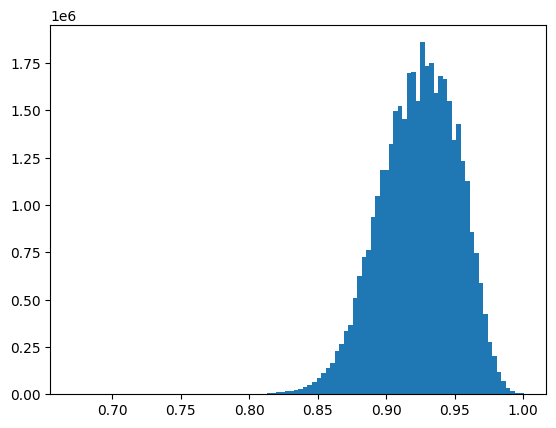

In [87]:
plt.hist(residuals.reshape(-1).cpu().detach().numpy(), bins=100);

In [88]:
dec_dist = inflated_decoder_learn.inject(residuals, v_dist)

In [89]:
loss = loss_fn(dec_dist, t_dist)

In [90]:
loss, old_original_loss

(tensor(400.5883, device='cuda:5', grad_fn=<DivBackward0>),
 tensor(401.0681, device='cuda:4'))